In [102]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix


# **1. Préparation des données**

On charge les données d'entrainement depuis le CSV et on fait les premières modification pour faciliter l'exploration.


In [67]:
df = pd.read_csv('./data/train.csv', sep=',')

#Encodage des maladies
encoder = {'Presence': 1, 'Absence': 0}
df['Heart Disease'] = df['Heart Disease'].map(encoder)

#Mettre la colonne id en index
df.set_index('id', inplace=True)

df.head(10)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
id,,,,,,,,,,,,,,
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1
5,38,1,4,138,283,0,0,147,1,1.6,2,2,7,1
6,59,1,4,130,246,0,2,152,0,0.8,2,2,3,1
7,60,0,3,120,245,0,0,151,0,1.2,1,0,3,0
8,48,0,4,140,212,0,2,125,0,0.0,1,0,3,0


# **2. Exploration des données (EDA)**

L'objectif est de mieux comprendre la structure du dataset, la répartition des features et le lien entre les varibales d'entrée et la target. Cela permet aussi de savoir comment traiter chacune des variables en fonction de leur structure (continue ou discrète, ordonnées ou non)

**Plan de la section** :

- 2.1 Tracé de la matrice de corrélation
- 2.2 Tracé des distributions des features
- 2.3 Encodage des variables non-ordonnées

# 2.1 Tracé de la matrice de corrélation

L'objectif du tracé de cette matrice est multiple : 

- Est-ce que deux ou plusieurs variables contiennent la mème information (relation linéaire) ?  Dans ce cas ces variables présentent des corrélations mutuelles prochent de 1

- Il-y-a t'il des variables qui sont frotement ou faiblement corrélées avec la cible ? On cherche donc des corrélations avec la cible soit particulièrement élevées, soit très faibles. 

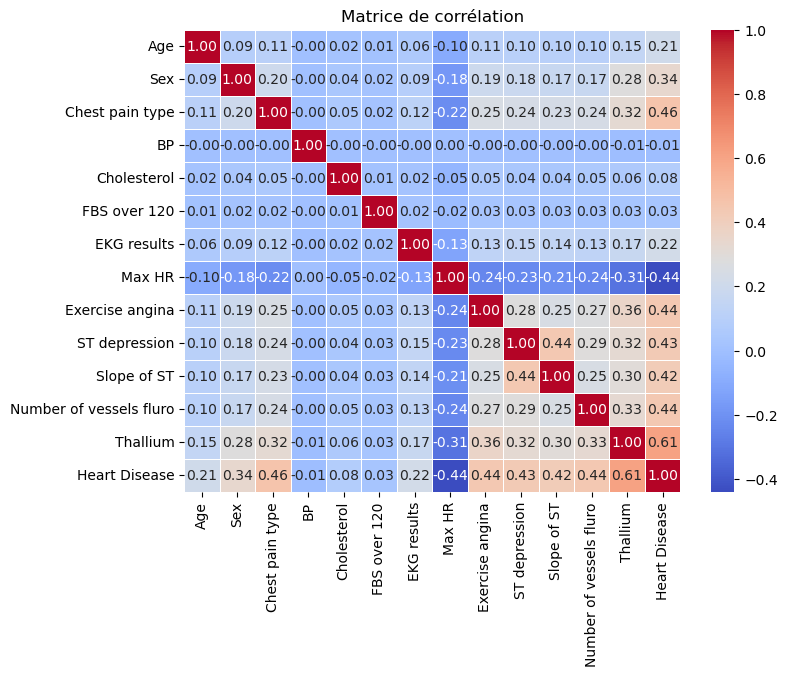

In [68]:
df.describe()

#Matrice de corrélation

plt.figure(figsize=(8, 6))
corr_matrix = df.corr().round(2)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Matrice de corrélation')

#On enlève les colonnes avec une faible corrélation avec la cible (Heart Disease)

df = df.drop(columns=['FBS over 120'])
df = df.drop(columns=['BP'])

#Remplacer 2 par 1 dans la colonne 'EKG results' pour indiquer la présence d'angine induite par l'exercice
df['EKG results'] = df['EKG results'].replace(2, 1)

# 2.2 Tracé des distributions des features

Dans cette section, on s'intéresse à connaitre la structure des features notamment pour s'assurer qu'elles sont exploitables par un algorithme de machine learning. 

On trace donc des graphes pour visualiser ces répartions. 

Si les features sont continues, on trace une distribution (au sens des probabilités)

Si les features sont discrètes, on trace des histogramme pour visualiser la répartition entre les classes

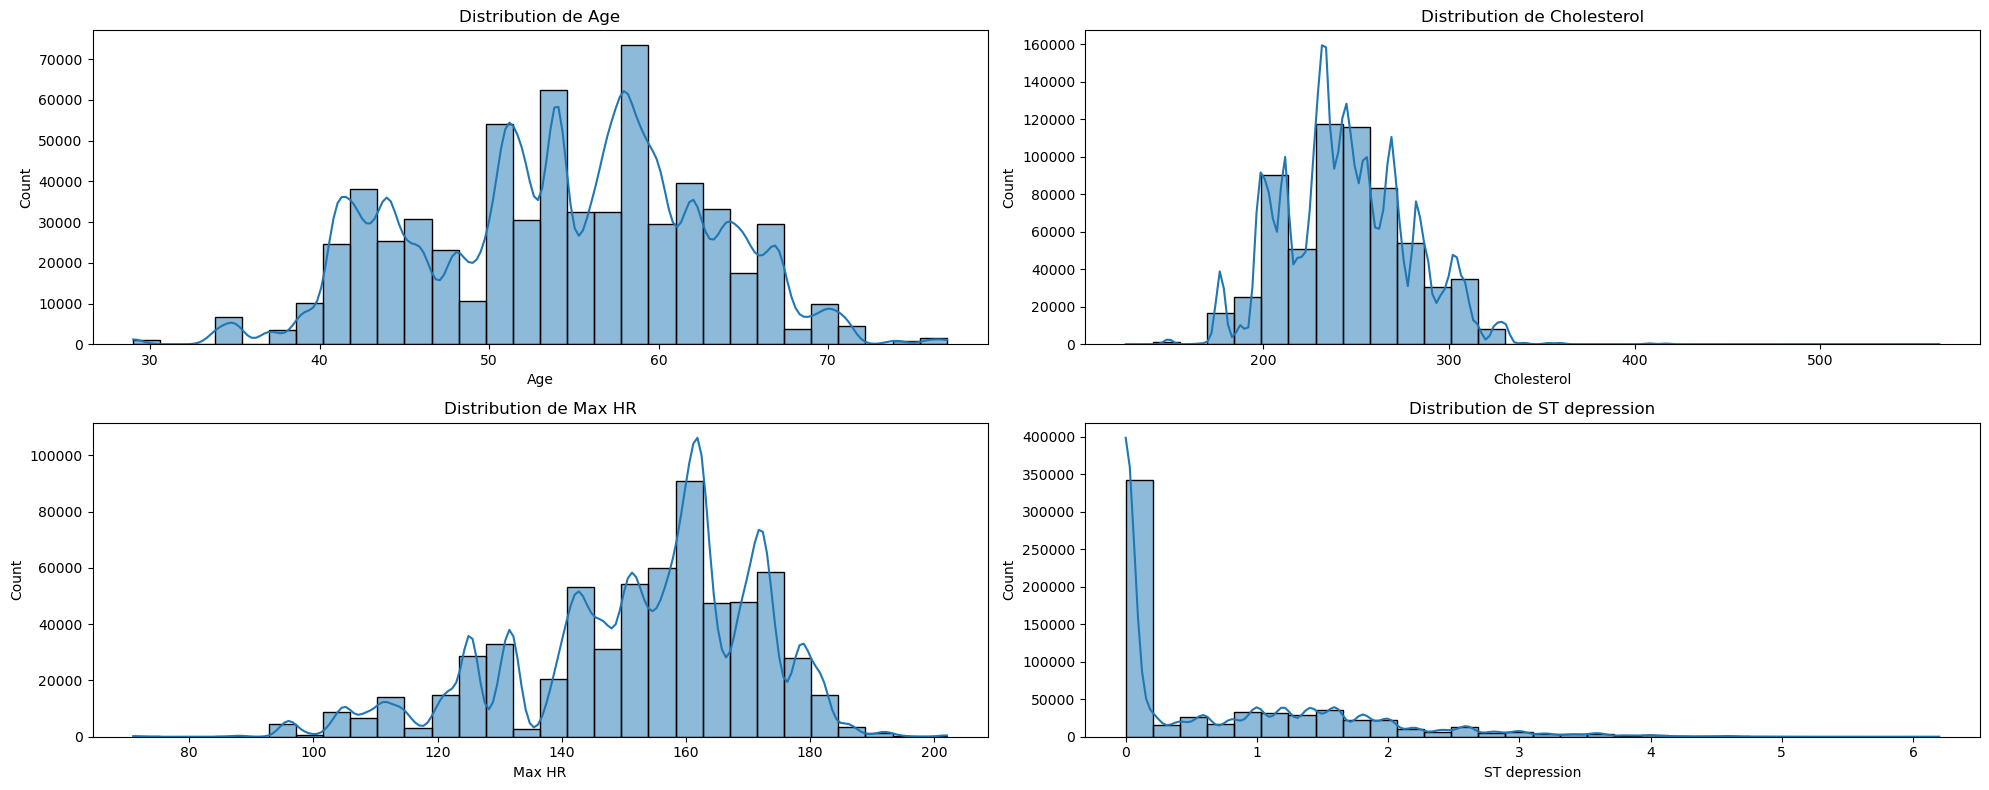

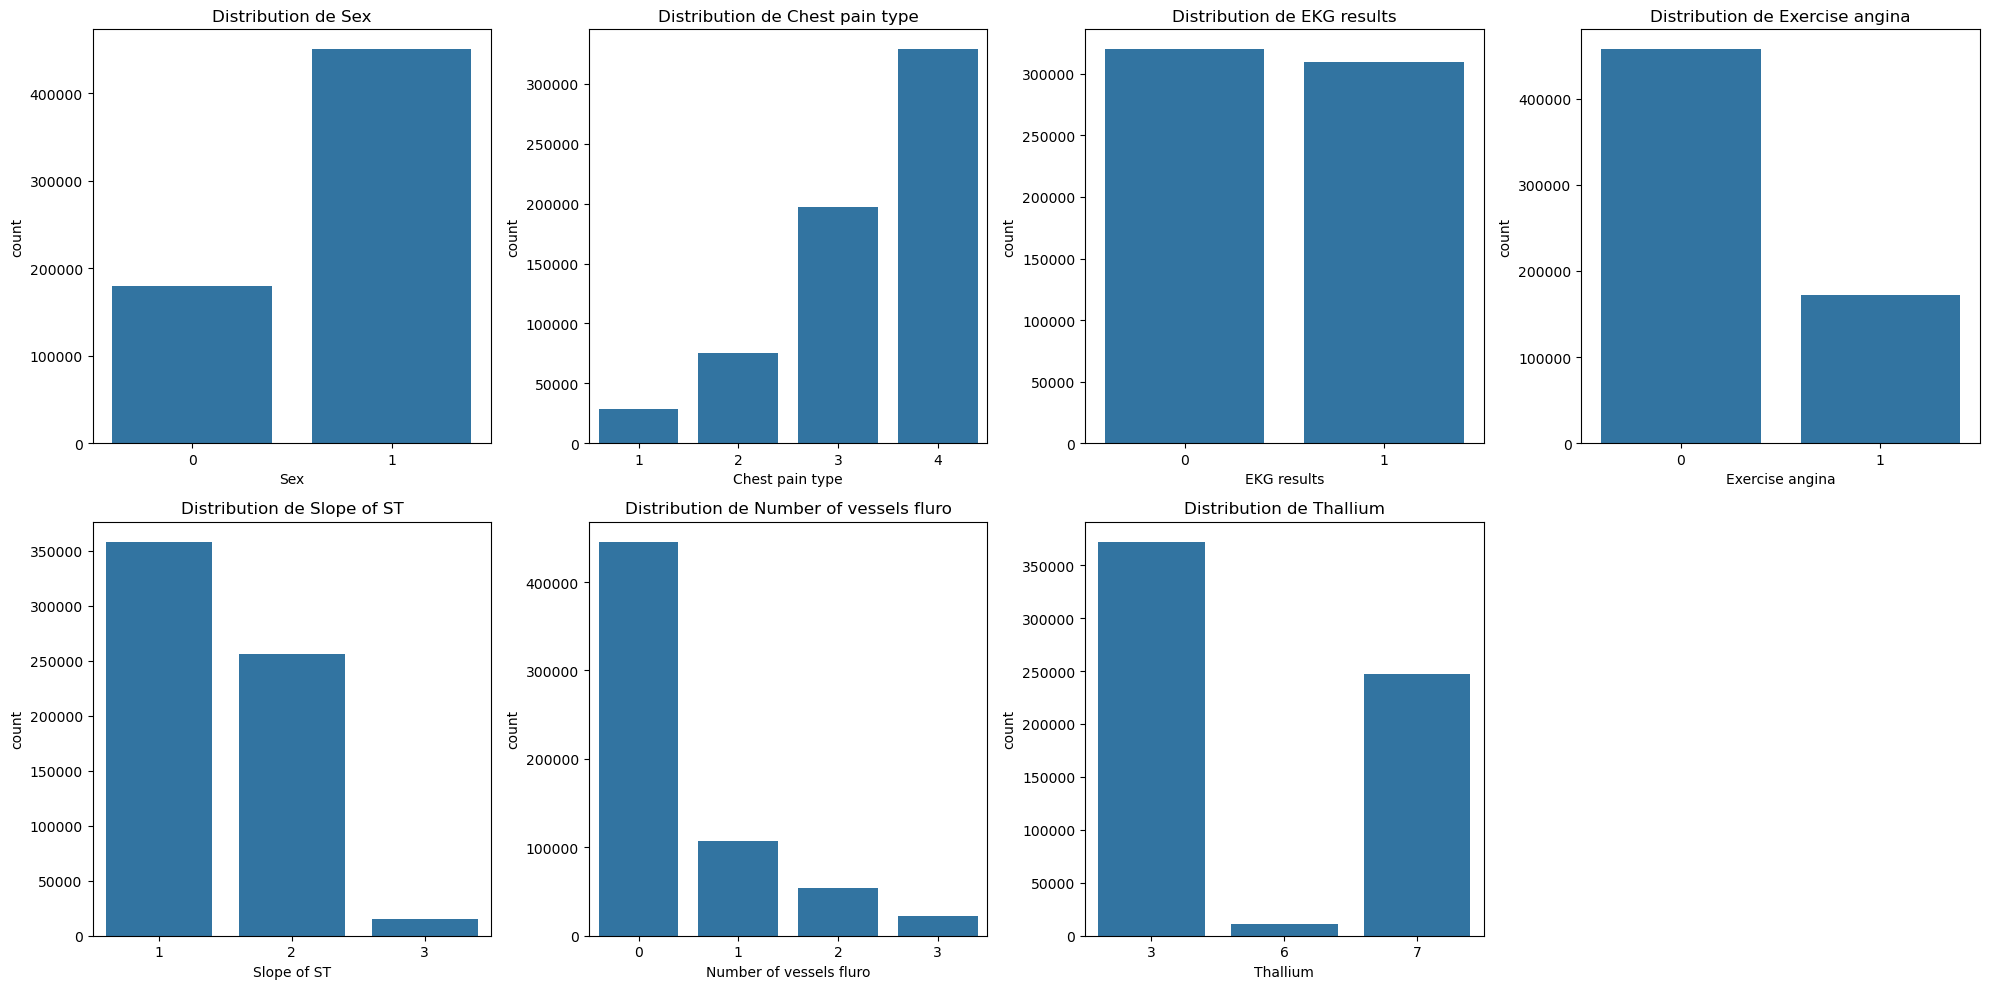

In [69]:
#Tracer les distributions des variables

#Variables continues (age, cholesterol, Max HR, ST depression) avec histplot
plt.figure(figsize=(20, 8))
for i, col in enumerate(['Age', 'Cholesterol', 'Max HR', 'ST depression']):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution de {col}')
plt.tight_layout()
plt.show()

#Variables discrètes (Sex, Chest Pain Type, Resting ECG, Exercise angina, ST Slope, Number of vessels fluro, Thallium) avec countplot
plt.figure(figsize=(20, 10))
discrete_vars = ['Sex', 'Chest pain type', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
for i, col in enumerate(discrete_vars):
    plt.subplot(2, 4, i+1)
    sns.countplot(x=df[col])
    plt.title(f'Distribution de {col}')
plt.tight_layout()
plt.show()




### 2.2.1. Zoom sur le cholestérol et l'équilibre des classes cibles

On remarque que le niveau de cholestérol présente un **phénomène de Queue** ("tail") de part et d'autre de la distribution. On cherche donc à comprendre si cela est inhérenet au données et si cela est intéressant pour la prédiction. On quantifie donc ce phénomène avec la détection d'outliers (basé sur la méthode IQR). Pour essayer de faire un lien, on s'intéresse aussi à la répartition des classes. 

On conclut alors que les outliers doivent ètre ramené dans des valeurs classiques car des taux extrèmes de cholestérol ne sont pas lié avec la chance de présence supplémentair de maladie. On utilise une méthode d'imputation basé sur la médianne.


Q1 de Cholesterol : 223.0
Q3 de Cholesterol : 269.0
IQR de Cholesterol : 46.0
Lower bound de Cholesterol : 154.0
Upper bound de Cholesterol : 338.0
Nombre de valeurs extrêmes dans Cholesterol : 2194
Ratio de valeurs extrêmes dans Cholesterol : 0.35%


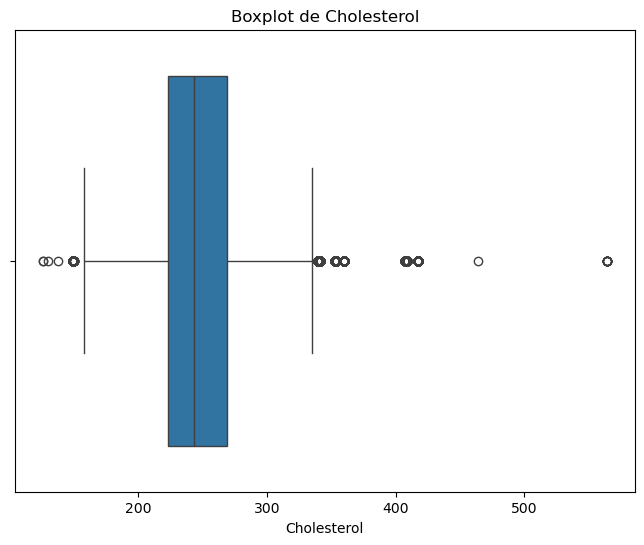

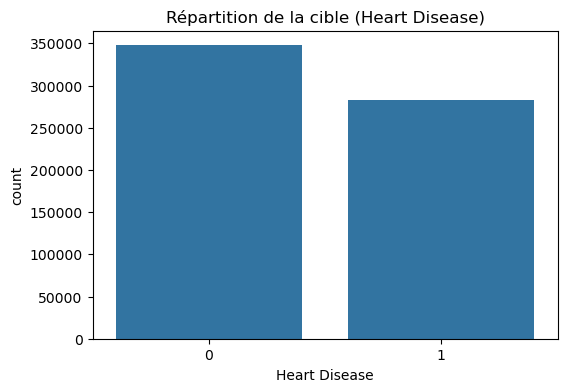

Ratio de malades parmi les outliers de Cholesterol : 29.26%
Ratio de malades dans le dataset : 44.83%


In [70]:
#Sortir les valeurs extrêmes de Cholesterol, méthode IQR
Q1 = df['Cholesterol'].quantile(0.25)
print(f'Q1 de Cholesterol : {Q1}')
Q3 = df['Cholesterol'].quantile(0.75)
print(f'Q3 de Cholesterol : {Q3}')
IQR = Q3 - Q1
print(f'IQR de Cholesterol : {IQR}')
lower_bound = Q1 - 1.5 * IQR
print(f'Lower bound de Cholesterol : {lower_bound}')
upper_bound = Q3 + 1.5 * IQR
print(f'Upper bound de Cholesterol : {upper_bound}')
outliers = df[(df['Cholesterol'] < lower_bound) | (df['Cholesterol'] > upper_bound)]
print(f'Nombre de valeurs extrêmes dans Cholesterol : {len(outliers)}')
ratio_outliers = len(outliers) / len(df)
print(f'Ratio de valeurs extrêmes dans Cholesterol : {ratio_outliers:.2%}')

#Graphiquement
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Cholesterol'])
plt.title('Boxplot de Cholesterol')
plt.show()

#Tracé de la target pour voir la répartition des classes
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Heart Disease'])
plt.title('Répartition de la cible (Heart Disease)')
plt.show()

#Taux d'outliers cholesterol malades

malades = df[df['Heart Disease'] == 1]
outliers_malades = malades[(malades['Cholesterol'] < lower_bound) | (malades['Cholesterol'] > upper_bound)]
ratio_outliers_malades = len(outliers_malades) / len(outliers)
print(f'Ratio de malades parmi les outliers de Cholesterol : {ratio_outliers_malades:.2%}')

#En séparant outliers positifs et négatifs
outliers_positifs = df[df['Cholesterol'] > upper_bound]
outliers_negatifs = df[df['Cholesterol'] < lower_bound]
ratio_malades = len(malades) / len(df)
print(f'Ratio de malades dans le dataset : {ratio_malades:.2%}')



On n'observe pas un déséquilibre de classe trop marqué. Pas de besoin à le prendre en compte dans la suite de l'analyse. On n'observe pas non plus de lien entre valeurs extrème de cholestérol et maladie. Par contre on observe un déséquilibre dans les sexes. On le prendras en compte en faisant une validation croisée stratifiée.

# 2.3 Encodage des variables non ordonnée

On fait l'encodage des variables discrètes non ordonnées (Chest pain type, EKG results, Slope of ST, Thallium) à l'aide d'un 'One-Hot Encoding'. Cela permet à l'algorithme de ne pas inventer des relations d'ordres sur des grandeurs qui n'en ont pas. 

In [71]:
#One-hot encoding des variables catégorielles ((Chest pain type, EKG results, Slope of ST, Thallium)

colonnes_a_encoder = ['Chest pain type', 'EKG results', 'Slope of ST', 'Thallium']
df = pd.get_dummies(df, columns=colonnes_a_encoder, drop_first=True, dtype=int)

df.head(5)


,Age,Sex,Cholesterol,Max HR,Exercise angina,ST depression,Number of vessels fluro,Heart Disease,Chest pain type_2,Chest pain type_3,Chest pain type_4,EKG results_1,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7
id,,,,,,,,,,,,,,,,
0,58,1,239,158,1,3.6,2,1,0,0,1,0,1,0,0,1
1,52,1,325,171,0,0.0,0,0,0,0,0,1,0,0,0,0
2,56,0,188,151,0,0.0,0,0,1,0,0,1,0,0,0,0
3,44,0,229,150,0,1.0,0,0,0,1,0,1,1,0,0,0
4,58,1,234,125,1,3.8,3,1,0,0,1,1,1,0,0,0


# 2.4 Feature engineering

Dans cette section, on chercher à créer de nouvelles features pour améliorer la précision du modèle.

Pour cela, on se base sur des indicateurs médicaux de références. 

In [ ]:
df['Severe_ST_Signal'] = df['ST depression'] * df['Slope of ST']
df['Silent_Ischemia'] = (df['Chest pain type_4'] == 1) & (df['Exercise angina'] == 1)

# 3. **Entrainement du modèle**

On va entrainer une **Random Forest**

Plan de la section : 
- 3.1 : Préparation du train set pour l'entrainement
- 3.2 : Hyper-parameters tuning
- 3.3 : Entrainement avec stratified CV à 5 folds (stratification sur la classe de sexe)


# 3.1 Préparation du train set

On met en forme les données du train set, notamment au regard des analyses précédentes.

In [72]:
# 1. Préparation initiale
X_train = df.drop(columns=['Heart Disease'])
y_train = df['Heart Disease']
stratify_target = X_train['Sex']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# 3.2 Hyper-parameters tuning

On va travailler avec un modèle basé sur **RandomForest**

On s'intéresse à trouver les meilleurs valeurs possible pour hyperparamètres suivants :

- **n_estimators_range** : nombre d'arbres dans la foret ;
- **max_depth_range** : profondeur de l'arbre.




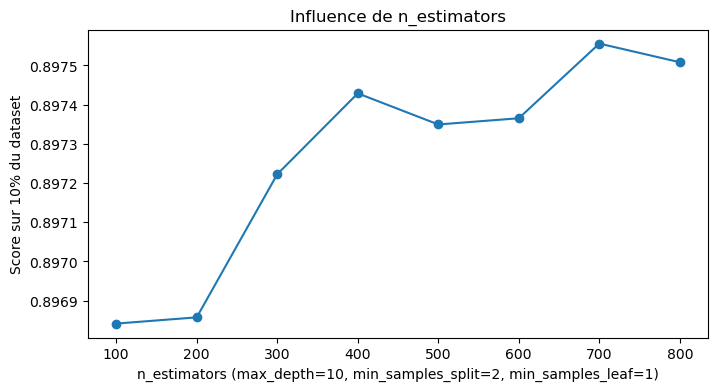

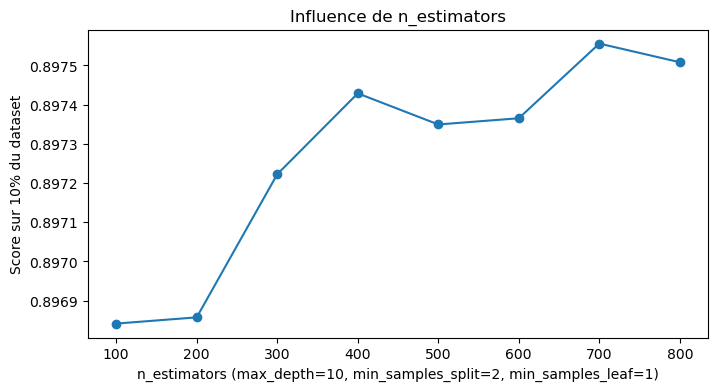

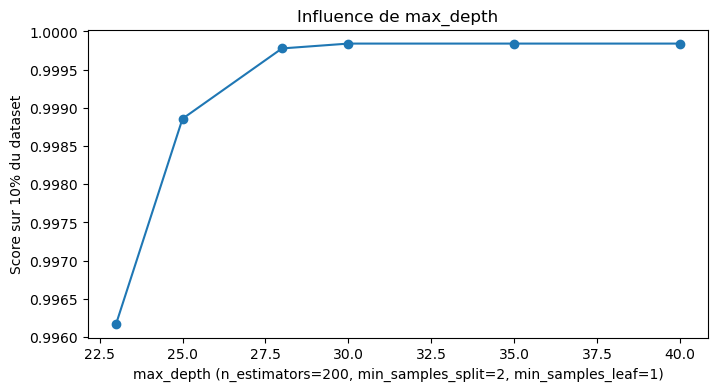

In [92]:
# Analyse manuelle de l'influence de chaque hyperparamètre (les autres fixés) sur 10% du dataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Sous-échantillon pour l'analyse
X_search, _, y_search, _ = train_test_split(X_train, y_train, test_size=0.9, random_state=42)

# Plages d'hyperparamètres à tester
n_estimators_range = [100, 200, 300, 400, 500, 600, 700, 800]
max_depth_range = [23, 25, 28, 30, 35, 40]

# Influence de n_estimators
scores = []
for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, max_depth=10, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', random_state=42)
    rf.fit(X_search, y_search)
    scores.append(rf.score(X_search, y_search))
plt.figure(figsize=(8, 4))
plt.plot(n_estimators_range, scores, 'o-')
plt.xlabel('n_estimators (max_depth=10, min_samples_split=2, min_samples_leaf=1)')
plt.ylabel('Score sur 10% du dataset')
plt.title('Influence de n_estimators')
plt.show()

# Influence de max_depth
scores = []
for d in max_depth_range:
    rf = RandomForestClassifier(n_estimators=200, max_depth=d, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', random_state=42)
    rf.fit(X_search, y_search)
    scores.append(rf.score(X_search, y_search))
plt.figure(figsize=(8, 4))
plt.plot(max_depth_range, scores, 'o-')
plt.xlabel('max_depth (n_estimators=200, min_samples_split=2, min_samples_leaf=1)')
plt.ylabel('Score sur 10% du dataset')
plt.title('Influence de max_depth')
plt.show()


On retient donc : 

- **n_estimators** = 700
- **max_depth** = 30 ('Elbow rule')

# 3.3 Entrainement de la random forest

On entraine une random forest sur 5 folds stratifiés selon le sexe du patient.

On utilise les hyperparamètres trouvés dans la section du dessus.

In [106]:
# 3. La boucle de validation croisée (Folding, Scaling+Imputing, Entrainement, Affichage des métriques d'évaluation)

# Initialisation des listes pour stocker les résultats de chaque fold
y_fold_val_list = []
preds_val_list = []
probas_val_list = []

for fold, (train_index, val_index) in enumerate(skf.split(X_train, stratify_target)):
    print(f'\nFold {fold+1}')
    
    # ÉTAPE A : Séparation des données pour ce fold
    X_fold_train = X_train.iloc[train_index].copy()
    X_fold_val = X_train.iloc[val_index].copy()
    y_fold_train = y_train.iloc[train_index]
    y_fold_val = y_train.iloc[val_index]
    
    # ÉTAPE B : Gestion des valeurs manquantes (Imputation)
    imputer = SimpleImputer(strategy='median')
    X_fold_train_imputed = pd.DataFrame(imputer.fit_transform(X_fold_train), columns=X_fold_train.columns, index=X_fold_train.index)
    X_fold_val_imputed = pd.DataFrame(imputer.transform(X_fold_val), columns=X_fold_val.columns, index=X_fold_val.index)
    
    # ÉTAPE C : Normalisation
    scaler = StandardScaler()
    X_fold_train_scaled = scaler.fit_transform(X_fold_train_imputed)
    X_fold_val_scaled = scaler.transform(X_fold_val_imputed)
    
    # ÉTAPE D : Entraînement
    # Utilisation des meilleurs hyperparamètres trouvés
    rf = RandomForestClassifier(n_estimators=700, max_depth=30, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', random_state=42)
    rf.fit(X_fold_train_scaled, y_fold_train)
    predictions = rf.predict(X_fold_val_scaled)
    probas = rf.predict_proba(X_fold_val_scaled)[:, 1]

    # Stockage des résultats pour ce fold
    y_fold_val_list.append(y_fold_val)
    preds_val_list.append(predictions)
    probas_val_list.append(probas)

    # Affichage du score
    score = accuracy_score(y_fold_val, predictions)
    print(f'Accuracy du modèle : {score * 100:.2f}%')


Fold 1
Accuracy du modèle : 87.76%

Fold 2
Accuracy du modèle : 87.77%

Fold 3
Accuracy du modèle : 87.94%

Fold 4
Accuracy du modèle : 87.74%

Fold 5
Accuracy du modèle : 87.71%


# 4. **Évaluation du modèle** : définitions et interprétations

- **Matrice de confusion** : permet d'afficher de manière condensée les :

    **TP** : vrais positifs ;

    **FP** : faux positifs ;

    **TN** : vrais négatifs ; 

    **FN** : faux négatifs.

- **Précision (Precision)** : proportion de prédictions positives correctes parmi toutes les prédictions positives.
  
  $$ \text{Précision} = \frac{TP}{TP + FP} $$
  
  *Interprétation : parmi les cas prédits comme malades, combien le sont réellement ?*

- **Rappel (Recall/Sensibilité)** : proportion de vrais positifs détectés parmi tous les cas positifs.
  
  $$ \text{Rappel} = \frac{TP}{TP + FN} $$
  
  *Interprétation : parmi tous les malades, combien sont détectés par le modèle ?*

- **Spécificité (Specificity)** : proportion de vrais négatifs détectés parmi tous les cas négatifs.
  
  $$ \text{Spécificité} = \frac{TN}{TN + FP} $$
  
  *Interprétation : parmi tous les non-malades, combien sont correctement identifiés ?*

- **F1 Score** : moyenne harmonique entre précision et rappel.
  
  $$ \text{F1} = 2 \times \frac{\text{Précision} \times \text{Rappel}}{\text{Précision} + \text{Rappel}} $$
  
  *Interprétation : équilibre entre la capacité à détecter les malades et à éviter les fausses alertes.*

  Cette métrique est très utile dans le cas de classe déséquilibrées, ce qui n'est pas le cas ici.

- **ROC AUC** : Elle évalue le compromis entre :

  La Sensibilité (Taux de Vrais Positifs) : Ta capacité à détecter tous les malades.

  La Spécificité (Taux de Faux Positifs) : Ta capacité à ne pas donner de fausses alertes aux gens sains.

  *Interprétation : "Si je prends un patient malade au hasard et un patient sain au hasard, quelle est la probabilité que mon modèle attribue un score de risque plus élevé au patient malade ?"*


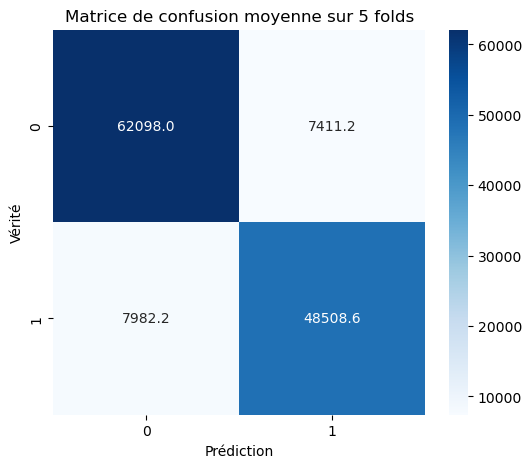

Précision moyenne : 0.867
Rappel (sensibilité) moyen : 0.859
Spécificité moyenne : 0.893
F1 score moyen : 0.863


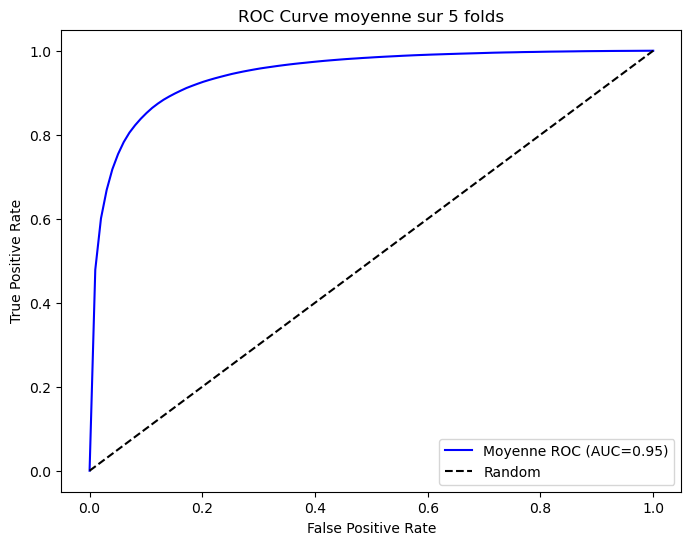

In [108]:
# Affichage des métriques et courbes sur les 5 folds (après entraînement et prétraitement)
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

auc_scores = []
mean_fpr = np.linspace(0, 1, 100)
tprs = []
conf_matrices = []
precision_scores = []
recall_scores = []
f1_scores = []
specificity_scores = []

for fold in range(5):
    # Utilise les prédictions et probabilités déjà calculées pour chaque fold
    # y_fold_val, preds_val, probas_val doivent être définis dans la boucle précédente
    # Ajoute ces variables dans une liste lors de l'entraînement pour les réutiliser ici
    cm = confusion_matrix(y_fold_val_list[fold], preds_val_list[fold])
    conf_matrices.append(cm)
    precision_scores.append(precision_score(y_fold_val_list[fold], preds_val_list[fold]))
    recall_scores.append(recall_score(y_fold_val_list[fold], preds_val_list[fold]))
    f1_scores.append(f1_score(y_fold_val_list[fold], preds_val_list[fold]))
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        specificity = 0
    specificity_scores.append(specificity)
    fpr, tpr, _ = roc_curve(y_fold_val_list[fold], probas_val_list[fold])
    auc = roc_auc_score(y_fold_val_list[fold], probas_val_list[fold])
    auc_scores.append(auc)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0

# Matrice de confusion moyenne
mean_cm = np.mean(conf_matrices, axis=0)

plt.figure(figsize=(6, 5))
sns.heatmap(mean_cm, annot=True, fmt='.1f', cmap='Blues')
plt.xlabel('Prédiction')
plt.ylabel('Vérité')
plt.title('Matrice de confusion moyenne sur 5 folds')
plt.show()

# Affichage des moyennes
print(f"Précision moyenne : {np.mean(precision_scores):.3f}")
print(f"Rappel (sensibilité) moyen : {np.mean(recall_scores):.3f}")
print(f"Spécificité moyenne : {np.mean(specificity_scores):.3f}")
print(f"F1 score moyen : {np.mean(f1_scores):.3f}")

# Courbe ROC moyenne
mean_tpr = np.mean(tprs, axis=0)
mean_auc = np.mean(auc_scores)
plt.figure(figsize=(8, 6))
plt.plot(mean_fpr, mean_tpr, color='b', label=f'Moyenne ROC (AUC={mean_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve moyenne sur 5 folds')
plt.legend()
plt.show()

On a une ROC AUC moyenne de 0.95 ce qui montre que notre modèle permet de très bien séparer les deux classes (malades et non malades).

# 5. **Préparation de la soumission**

Dans la section qui suit, on prépare la soumission de la prédiction au format voulut. On s'intéresse donc au test.csv

In [ ]:
# 1. Charger le fichier test
test = pd.read_csv('./data/test.csv', sep=',')
test_ids = test['id']
test.set_index('id', inplace=True)

# 2. Nettoyage
test = test.drop(columns=['FBS over 120', 'BP'])
test['EKG results'] = test['EKG results'].replace(2, 1)

# 3. Encodage
test = pd.get_dummies(test, columns=colonnes_a_encoder, drop_first=True, dtype=int)

# Sécurité : On force le test à avoir exactement les mêmes colonnes que le X_train de ton modèle
test = test.reindex(columns=X_train.columns, fill_value=0) # Si une colonne manque, il la crée remplie de 0.

# 4. Imputer + Normaliser + Prédiction en probas
test_imputed = imputer.transform(test)
test_final = pd.DataFrame(test_imputed, columns=X_train.columns, index=test.index)
test_final = pd.DataFrame(scaler.transform(test_final), columns=X_train.columns, index=test.index)
probas = rf.predict_proba(test_final)[:, 1]

# 5. Création du fichier de soumission
submission = pd.DataFrame({
    'id': test_ids,
    'Heart Disease': probas
})

submission.to_csv('submission_finale1.csv', index=False)

print(f"Fichier csv de soumission créé avec succés !")

c:\Users\gauja\miniconda3\envs\kaggle_project\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Fichier csv de soumission créé avec succés !
